Tutorial original en ultralytics

https://colab.research.google.com/github/ultralytics/ultralytics/blob/main/examples/tutorial.ipynb#scrollTo=bpF9-vS_DAaf


App para anotar/etiquetar imágenes de nuestra propia base de datos:

https://app.roboflow.com/login

In [1]:
%pip install ultralytics
import ultralytics
ultralytics.checks()

Ultralytics 8.4.147  Python-3.12.10 torch-2.14.0+cpu CPU (AMD Ryzen 7 7730U with Radeon Graphics)


Setup complete  (16 CPUs, 14.8 GB RAM, 305.0/474.7 GB disk)


# 1. Predict

YOLOv8 may be used directly in the Command Line Interface (CLI) with a `yolo` command for a variety of tasks and modes and accepts additional arguments, i.e. `imgsz=640`. See a full list of available `yolo` [arguments](https://docs.ultralytics.com/usage/cfg/) and other details in the [YOLOv8 Predict Docs](https://docs.ultralytics.com/modes/train/).

In [2]:
# Run inference on an image with YOLOv8n
# NOTA (entorno local): dentro del kernel de Jupyter 'yolo' puede no
# estar en el PATH del subproceso aunque el paquete si este instalado;
# resolvemos la ruta completa a partir de sys.executable. En Colab esto
# no hace falta (ahi 'yolo' si esta en el PATH), pero no estorba.
import sys, os
yolo_exe = os.path.join(os.path.dirname(sys.executable), 'yolo.exe' if os.name == 'nt' else 'yolo')

!"{yolo_exe}" predict model=yolov8n.pt source='https://ultralytics.com/images/zidane.jpg'


Ultralytics 8.4.147  Python-3.12.10 torch-2.14.0+cpu CPU (AMD Ryzen 7 7730U with Radeon Graphics)
YOLOv8n summary (fused): 72 layers, 3,151,904 parameters, 0 gradients, 8.7 GFLOPs

Found https://ultralytics.com/images/zidane.jpg locally at zidane.jpg
image 1/1 C:\xampp\htdocs\Introduccion-a-la-inteligencia-artificial\06_Vision_computacional\notebooks_colab\zidane.jpg: 384x640 2 persons, 1 tie, 137.4ms
Speed: 10.0ms preprocess, 137.4ms inference, 28.3ms postprocess per image at shape (1, 3, 384, 640)
Results saved to C:\xampp\htdocs\Introduccion-a-la-inteligencia-artificial\06_Vision_computacional\notebooks_colab\runs\detect\predict
 Learn more at https://docs.ultralytics.com/modes/predict


## 1. Detection

YOLOv8 _detection_ models have no suffix and are the default YOLOv8 models, i.e. `yolov8n.pt` and are pretrained on COCO. See [Detection Docs](https://docs.ultralytics.com/tasks/detect/) for full details.

In [3]:
# Load YOLOv8n, train it on COCO128 for 3 epochs and predict an image with it
from ultralytics import YOLO

model = YOLO('yolov8n.pt')  # load a pretrained YOLOv8n detection model
model.train(data='coco128.yaml', epochs=3)  # train the model
model('https://ultralytics.com/images/bus.jpg', save=True)  # predict on an image

Ultralytics 8.4.147  Python-3.12.10 torch-2.14.0+cpu CPU (AMD Ryzen 7 7730U with Radeon Graphics)


engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=coco128.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=3, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=None, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, pose=12.0, pretrai


                   from  n    params  module                                       arguments                     


  0                  -1  1       464  ultralytics.nn.modules.conv.Conv             [3, 16, 3, 2]                 


  1                  -1  1      4672  ultralytics.nn.modules.conv.Conv             [16, 32, 3, 2]                


...

Found https://ultralytics.com/images/bus.jpg locally at bus.jpg


image 1/1 C:\xampp\htdocs\Introduccion-a-la-inteligencia-artificial\06_Vision_computacional\notebooks_colab\bus.jpg: 640x480 4 persons, 1 bus, 1 stop sign, 85.3ms


Speed: 6.4ms preprocess, 85.3ms inference, 3.6ms postprocess per image at shape (1, 3, 640, 480)


Results saved to C:\xampp\htdocs\Introduccion-a-la-inteligencia-artificial\06_Vision_computacional\notebooks_colab\runs\detect\predict-2


[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 depth: None
 keypoints: None
 masks: None
 names: {0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch', 

## Mi propia imagen

Corre primero las celdas de arriba **sin cambios** (Zidane y bus) y guarda esas salidas. Despues, sube tu propia foto al panel de archivos de Colab (icono de carpeta a la izquierda -> arrastra el archivo) o usa una URL publica a un `.jpg`/`.png`. Cambia **solo** la variable `MI_FOTO` de la celda de abajo -- deja todo lo demas igual (mismo modelo `yolov8n.pt`, mismas `epochs=3`, mismo `coco128.yaml`).

La foto debe mostrar al menos un objeto que COCO sepa nombrar (persona, perro, silla, auto, taza, laptop, etc.), no un logo o un recorte abstracto.

In [4]:
# Foto real del usuario.
MI_FOTO = 'mi_foto.png'


### Prediccion CLI sobre mi foto

Mismo comando que la celda de Zidane, apuntando a `MI_FOTO`.

Ultralytics 8.4.147  Python-3.12.10 torch-2.14.0+cpu CPU (AMD Ryzen 7 7730U with Radeon Graphics)
YOLOv8n summary (fused): 72 layers, 3,151,904 parameters, 0 gradients, 8.7 GFLOPs

image 1/1 C:\xampp\htdocs\Introduccion-a-la-inteligencia-artificial\06_Vision_computacional\notebooks_colab\mi_foto.png: 320x640 4 persons, 59.7ms
Speed: 2.8ms preprocess, 59.7ms inference, 2.0ms postprocess per image at shape (1, 3, 320, 640)
Results saved to C:\xampp\htdocs\Introduccion-a-la-inteligencia-artificial\06_Vision_computacional\notebooks_colab\runs\detect\predict-3
 Learn more at https://docs.ultralytics.com/modes/predict
Resultado CLI guardado en: runs/detect\predict-3\mi_foto.jpg


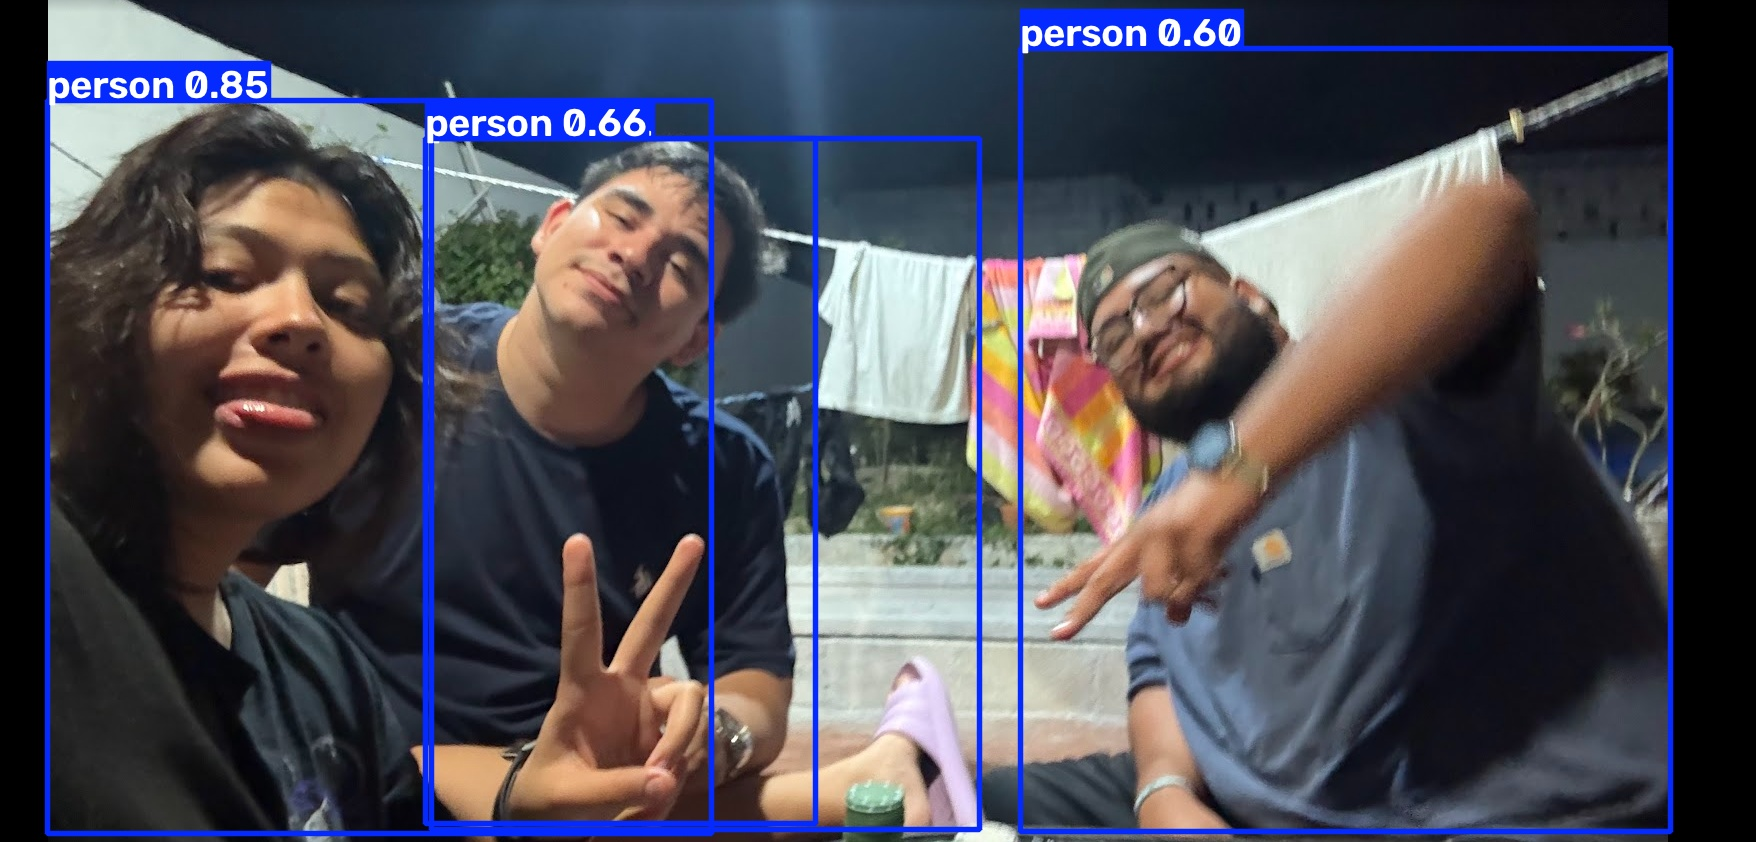

In [5]:
# Resolvemos la ruta completa de yolo.exe: dentro del kernel de Jupyter
# el comando 'yolo' puede no estar en el PATH del subproceso aunque el
# paquete si este instalado (mismo problema que con 'python' vs su ruta
# completa). Usamos sys.executable para ubicar el venv y de ahi su Scripts/.
import sys, os
yolo_exe = os.path.join(os.path.dirname(sys.executable), 'yolo.exe' if os.name == 'nt' else 'yolo')

!"{yolo_exe}" predict model=yolov8n.pt source='{MI_FOTO}'

import glob
from IPython.display import Image, display

latest_predict_dir = max(glob.glob('runs/detect/predict*'), key=os.path.getmtime)
candidates = glob.glob(f'{latest_predict_dir}/*.jpg') + glob.glob(f'{latest_predict_dir}/*.png') + glob.glob(f'{latest_predict_dir}/*.jpeg')
img_path = max(candidates, key=os.path.getmtime)
print('Resultado CLI guardado en:', img_path)
display(Image(filename=img_path))


### Prediccion con `model(...)` sobre la misma foto

Mismo modelo ya entrenado 3 epocas arriba (`model`), misma imagen `MI_FOTO` -- para comparar si la celda CLI y esta coinciden, como pide el reporte.

image 1/1 C:\xampp\htdocs\Introduccion-a-la-inteligencia-artificial\06_Vision_computacional\notebooks_colab\mi_foto.png: 320x640 3 persons, 54.5ms


Speed: 2.6ms preprocess, 54.5ms inference, 0.9ms postprocess per image at shape (1, 3, 320, 640)


Results saved to C:\xampp\htdocs\Introduccion-a-la-inteligencia-artificial\06_Vision_computacional\notebooks_colab\runs\detect\predict-2


Resultado model() guardado en: runs/detect\predict-2\mi_foto.jpg


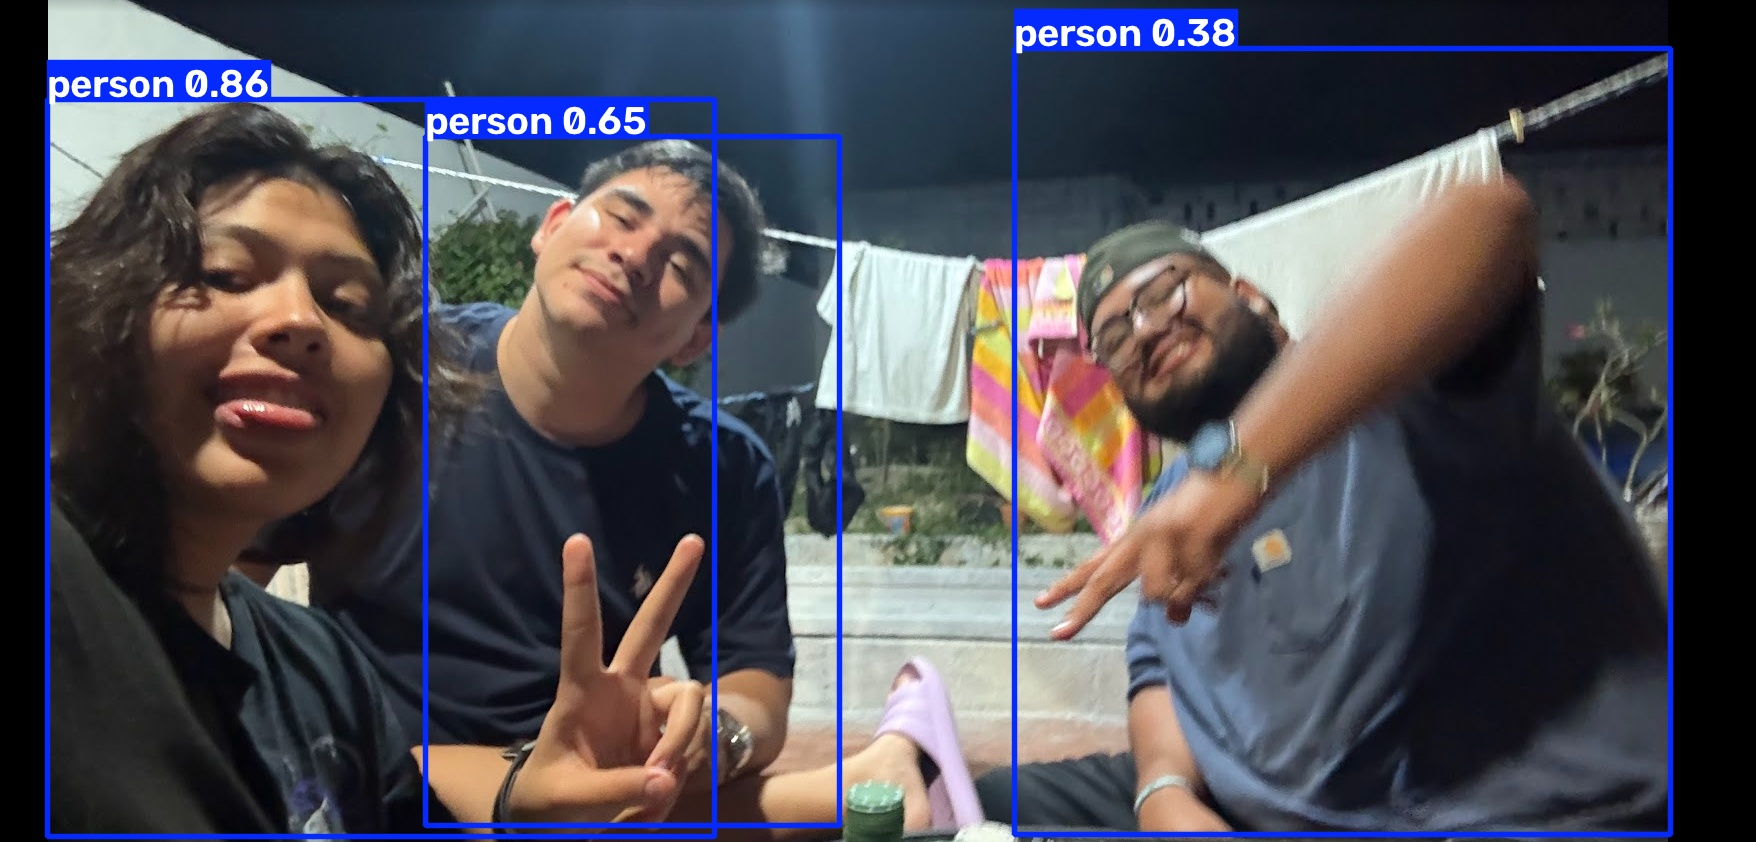

person: 0.86
person: 0.65
person: 0.38


In [6]:
results = model(MI_FOTO, save=True)

import glob, os
from IPython.display import Image, display

latest_predict_dir = max(glob.glob('runs/detect/predict*'), key=os.path.getmtime)
candidates = glob.glob(f'{latest_predict_dir}/*.jpg') + glob.glob(f'{latest_predict_dir}/*.png') + glob.glob(f'{latest_predict_dir}/*.jpeg')
img_path = max(candidates, key=os.path.getmtime)
print('Resultado model() guardado en:', img_path)
display(Image(filename=img_path))

# Clases detectadas y su confianza, para el reporte
for r in results:
    for box in r.boxes:
        cls_name = r.names[int(box.cls)]
        conf = float(box.conf)
        print(f'{cls_name}: {conf:.2f}')
